# OLD CODE

In [48]:
import os
from PIL import Image
import numpy as np

root_dir = "data"
os.makedirs(root_dir, exist_ok=True)

# Create class folders and dummy images
classes = ["cat", "dog"]

for cls in classes:
    cls_dir = os.path.join(root_dir, cls)
    os.makedirs(cls_dir, exist_ok=True)
    for i in range(5): # Create 5 dummy images per class
        # Create a simple black / white dummy image

        img_array = np.zeros((32, 32, 3), dtype=np.uint8) 
        if cls == "dog":
            img_array.fill(255) # Dogs will be white image

        img = Image.fromarray(img_array)
        img.save(os.path.join(cls_dir, f"{cls}_{i}.png"))

print("Synthetic data created")



Synthetic data created


EDA for data
Found classes : ['cat', 'dog']
 - Class 'cat' : 6 images
 - Class 'dog' : 5 images
5

Sample imaeg from data\cat\cat_0.png 
Format : PNG
Size : (32, 32)
Mode : RGB


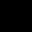

In [49]:
# Perform EDA
import glob

print(f"EDA for {root_dir}")

# Find all class directories
class_dirs = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]
print(f"Found classes : {class_dirs}")

# Count images in each class

for cls in class_dirs:
    num_images = len(glob.glob(os.path.join(root_dir, cls, "*")))
    print(f" - Class '{cls}' : {num_images} images")

# Display one sample here
sample_path = glob.glob(os.path.join(root_dir, "cat", "*"))[0]
sample_image = Image.open(sample_path)

print(num_images
      )
print(f"\nSample imaeg from {sample_path} ")
print(f"Format : {sample_image.format}")
print(f"Size : {sample_image.size}")
print(f"Mode : {sample_image.mode}")
sample_image

In [50]:
# Building the CustomImageDataset
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class CustomImageDataset(Dataset):
    def __init__(self, root_dir, transform = None):
        self.root_dir = root_dir
        self.transform = transform
        # Discover classes from folder names
        self.classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

        # Find all image paths to assign labels
        self.image_paths = []
        self.labels = []
        for cls_name in self.classes:
            cls_idx = self.class_to_idx[cls_name]
            cls_dir = os.path.join(root_dir, cls_name)
            for img_path in glob.glob(os.path.join(cls_dir, "*")):
                self.image_paths.append(img_path)
                self.labels.append(cls_idx)
    
    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):

        # Load the image
        img_path = self.image_paths[index]
        image = Image.open(img_path).convert("RGB") # Ensure three channels
        # Get label

        label = self.labels[index]
        if self.transform:
            image = self.transform(image)

        return image, label
    

# Test the Dataset and Dataloader
# Define transforms
data_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std = [0.5, 0.5, 0.5])
])

# Instantiate the dataset
clinical_dataset = CustomImageDataset(root_dir=root_dir, transform=data_transform)


# Create a loader
clinical_loader = DataLoader(clinical_dataset, batch_size = 4, shuffle=True)


# Fetch one label to verify

images, labels = next(iter(clinical_loader))

print(f"\n--- DataLoader Test ---")
print(f"Batch of images shape: {images.shape}") # Should be [4, 3, 32, 32]
print(f"Batch of labels shape: {labels.shape}")   # Should be [4]
print(f"Labels in batch: {labels}")


--- DataLoader Test ---
Batch of images shape: torch.Size([4, 3, 32, 32])
Batch of labels shape: torch.Size([4])
Labels in batch: tensor([0, 0, 0, 0])


### beginner



> In the __getitem__ method, add a print(f"Loading image: {img_path}") statement. Then, iterate through a few batches of the clinical_loader. Observe the order in which images are loaded. Does it change if you set shuffle=False in the DataLoader?

In [51]:
# Building the CustomImageDataset
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class CustomImageDataset(Dataset):
    def __init__(self, root_dir, transform = None):
        self.root_dir = root_dir
        self.transform = transform
        # Discover classes from folder names
        self.classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

        # Find all image paths to assign labels
        self.image_paths = []
        self.labels = []
        for cls_name in self.classes:
            cls_idx = self.class_to_idx[cls_name]
            cls_dir = os.path.join(root_dir, cls_name)
            for img_path in glob.glob(os.path.join(cls_dir, "*")):
                self.image_paths.append(img_path)
                self.labels.append(cls_idx)
    
    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):

        # Load the image
        img_path = self.image_paths[index]
        image = Image.open(img_path).convert("RGB") # Ensure three channels
        # Get label
        print(f"Loading image : {img_path}")
        label = self.labels[index]
        if self.transform:
            image = self.transform(image)

        return image, label
    

# Test the Dataset and Dataloader
# Define transforms
data_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std = [0.5, 0.5, 0.5])
])

# Instantiate the dataset
clinical_dataset = CustomImageDataset(root_dir=root_dir, transform=data_transform)


# Create a loader
clinical_loader = DataLoader(clinical_dataset, batch_size = 4, shuffle=False)


# Fetch one label to verify

images, labels = next(iter(clinical_loader))

print(f"\n--- DataLoader Test ---")
print(f"Batch of images shape: {images.shape}") # Should be [4, 3, 32, 32]
print(f"Batch of labels shape: {labels.shape}")   # Should be [4]
print(f"Labels in batch: {labels}")

Loading image : data\cat\cat_0.png
Loading image : data\cat\cat_1.png
Loading image : data\cat\cat_2.png
Loading image : data\cat\cat_3.png

--- DataLoader Test ---
Batch of images shape: torch.Size([4, 3, 32, 32])
Batch of labels shape: torch.Size([4])
Labels in batch: tensor([0, 0, 0, 0])


### Intermediate

> Modify the __init__ method to handle a scenario where there are non-image files (e.g., .txt or .DS_Store) in the class folders. Your glob.glob should be more specific to only pick up files with extensions like .png, .jpg, .jpeg.

In [52]:
# Building the CustomImageDataset
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class CustomImageDataset(Dataset):
    def __init__(self, root_dir, transform = None):
        self.root_dir = root_dir
        self.transform = transform
        # Discover classes from folder names
        self.classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

        # Find all image paths to assign labels
        self.image_paths = []
        self.labels = []
        for cls_name in self.classes:
            cls_idx = self.class_to_idx[cls_name]
            cls_dir = os.path.join(root_dir, cls_name)
            for img_path in glob.glob(os.path.join(cls_dir, "*")):
                self.image_paths.append(img_path)
                self.labels.append(cls_idx)
    
    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):

        # Load the image
        img_path = self.image_paths[index]
        image = Image.open(img_path).convert("RGB") # Ensure three channels
        # Get label
        label = self.labels[index]
        if self.transform:
            image = self.transform(image)

        return image, label
    

# Test the Dataset and Dataloader
# Define transforms
data_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std = [0.5, 0.5, 0.5])
])

# Instantiate the dataset
clinical_dataset = CustomImageDataset(root_dir=root_dir, transform=data_transform)


# Create a loader
clinical_loader = DataLoader(clinical_dataset, batch_size = 4, shuffle=True)


# Fetch one label to verify

images, labels = next(iter(clinical_loader))

print(f"\n--- DataLoader Test ---")
print(f"Batch of images shape: {images.shape}") # Should be [4, 3, 32, 32]
print(f"Batch of labels shape: {labels.shape}")   # Should be [4]
print(f"Labels in batch: {labels}")


--- DataLoader Test ---
Batch of images shape: torch.Size([4, 3, 32, 32])
Batch of labels shape: torch.Size([4])
Labels in batch: tensor([1, 1, 0, 0])


### Advanced

> What happens if an image file is corrupted and Image.open() fails? The current code will crash the whole training process. Modify __getitem__ to use a try...except block. If an image fails to load, it should print a warning and load the next valid image in the dataset instead.



In [53]:
# Building the CustomImageDataset
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class CustomImageDataset(Dataset):
    def __init__(self, root_dir, transform = None):
        self.root_dir = root_dir
        self.transform = transform
        # Discover classes from folder names
        self.classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

        # Find all image paths to assign labels
        self.image_paths = []
        self.labels = []
        for cls_name in self.classes:
            cls_idx = self.class_to_idx[cls_name]
            cls_dir = os.path.join(root_dir, cls_name)
            for img_path in glob.glob(os.path.join(cls_dir, "*")):
                self.image_paths.append(img_path)
                self.labels.append(cls_idx)
    
    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        while True:
            img_path = self.image_paths[index]
            try:
                image = Image.open(img_path).convert("RGB")
                label = self.labels[index]
                if self.transform:
                    image = self.transform(image)
                return image, label
            except Exception as e:
                print(f"Warning: Could not load image {img_path}. Error: {e}")
                index = (index + 1) % len(self.image_paths)

    

# Test the Dataset and Dataloader
# Define transforms
data_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std = [0.5, 0.5, 0.5])
])

# Instantiate the dataset
clinical_dataset = CustomImageDataset(root_dir=root_dir, transform=data_transform)


# Create a loader
clinical_loader = DataLoader(clinical_dataset, batch_size = 4, shuffle=True)


# Fetch one label to verify

images, labels = next(iter(clinical_loader))

print(f"\n--- DataLoader Test ---")
print(f"Batch of images shape: {images.shape}") # Should be [4, 3, 32, 32]
print(f"Batch of labels shape: {labels.shape}")   # Should be [4]
print(f"Labels in batch: {labels}")


--- DataLoader Test ---
Batch of images shape: torch.Size([4, 3, 32, 32])
Batch of labels shape: torch.Size([4])
Labels in batch: tensor([1, 1, 1, 1])
